In [1]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("Dataset/Raw_Churn_Modelling_Data.csv")
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [3]:
df = df.drop(["RowNumber", "CustomerId", "Surname"], axis=1)
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In this step, irrelevant columns are removed. These columns represent identifiers (RowNumber, CustomerId, Surname) and do not contribute to clustering or pattern discovery.

In [4]:
df = df.drop("Exited", axis=1)

The target variable "Exited" is removed because clustering is an unsupervised learning technique. Unlike supervised learning, clustering does not use labeled data and instead groups data based on similarity.

In [5]:
label_encoder = LabelEncoder()

df["Gender"] = label_encoder.fit_transform(df["Gender"])
df["Geography"] = label_encoder.fit_transform(df["Geography"])

Categorical variables such as Gender and Geography are converted into numerical values using Label Encoding. This is required because clustering algorithms like K-Means only work with numerical data.

In [6]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

Feature scaling is applied using StandardScaler to standardize the data. This ensures that all features contribute equally to the clustering process, preventing features with larger values from dominating the results.

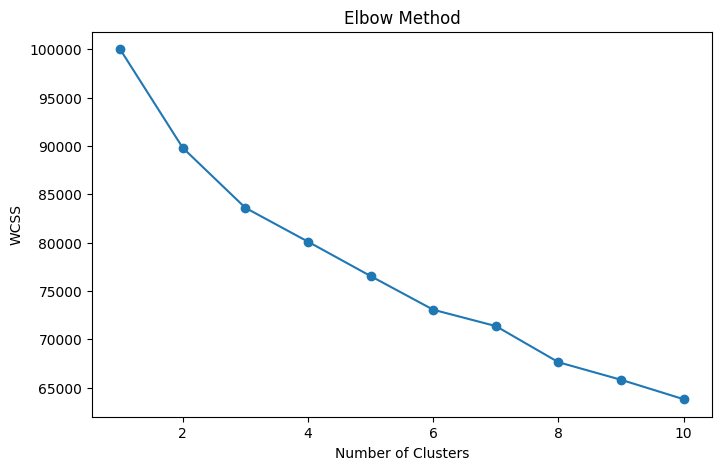

In [7]:
wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(1,11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

The Elbow Method is used to determine the optimal number of clusters. It measures the Within-Cluster Sum of Squares (WCSS) for different values of k.
The goal is to identify the point where adding more clusters does not significantly reduce WCSS. This point is known as the "elbow".

Based on the Elbow Method plot, the WCSS decreases sharply until k = 3, after which the rate of decrease slows down.
This indicates that the optimal number of clusters is approximately 3, as adding more clusters beyond this point provides diminishing returns.
Therefore, k = 3 is selected as the optimal number of clusters.

In [8]:
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

df["Cluster"] = clusters
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Cluster
0,619,0,0,42,2,0.00,1,1,1,101348.88,0
1,608,2,0,41,1,83807.86,1,0,1,112542.58,0
2,502,0,0,42,8,159660.80,3,1,0,113931.57,0
3,699,0,0,39,1,0.00,2,0,0,93826.63,1
4,850,2,0,43,2,125510.82,1,1,1,79084.10,0


K-Means clustering is applied using k = 3. Each data point is assigned to one of the three clusters based on similarity.

A new column "Cluster" is added to the dataset to store the cluster label for each customer.

In [9]:
df["Cluster"].value_counts()

Cluster
2    3489
1    3307
0    3204
Name: count, dtype: int64

This step shows the number of data points assigned to each cluster. It helps us understand how the data is distributed across clusters and whether the clusters are balanced or not.

In [10]:
cluster_profile = df.groupby("Cluster").mean()
cluster_profile

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
Cluster,,,,,,,,,,
0,650.096754,0.770599,0.000000,39.627341,4.926654,103722.972232,1.293383,0.700062,0.494070,100964.051657
1,650.998488,0.602661,0.595101,38.144542,5.107953,7924.892238,2.009979,0.715150,0.521318,99287.316997
2,650.480367,0.860132,1.000000,39.010605,5.001720,116458.260596,1.292921,0.701347,0.528518,100048.844938


This table represents the average values of each feature within each cluster. It helps us understand the characteristics of each group and identify patterns that differentiate the clusters.

Although the numerical values appear close due to scaling, meaningful differences can still be observed between clusters.

Cluster 1 is clearly distinct with significantly lower balance and a higher number of products compared to other clusters.

Cluster 0 and Cluster 2 show higher balances, but differ in gender distribution, where Cluster 2 is predominantly female.

These differences indicate that the clustering model successfully identified distinct customer segments based on behavioral and demographic patterns.

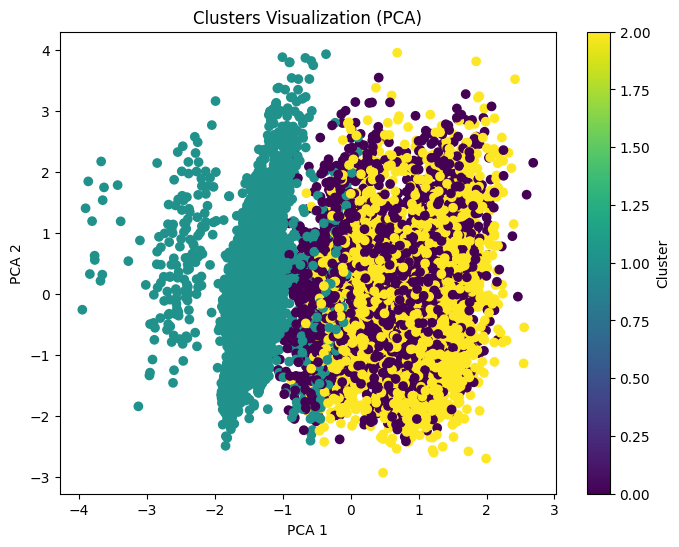

In [11]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=df["Cluster"], cmap="viridis")
plt.title("Clusters Visualization (PCA)")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.colorbar(label="Cluster")
plt.show()

Since the dataset has multiple dimensions, PCA is used to reduce it to 2 dimensions for visualization.
The scatter plot shows how data points are grouped into clusters. Each color represents a different cluster, allowing us to visually inspect the separation between groups.

The PCA visualization shows how the data points are grouped into three clusters.

Cluster 1 appears clearly separated on the left side of the plot, indicating that it represents a distinct group of customers with unique characteristics.

However, Cluster 0 and Cluster 2 show noticeable overlap in the central region, suggesting that these two groups share similar feature patterns and are less distinctly separated.

This indicates that while the clustering model successfully identified one well-defined cluster, the remaining clusters have some similarities, which is common in real-world datasets.

Overall, the clustering provides useful segmentation, but the separation between some groups is not very strong.